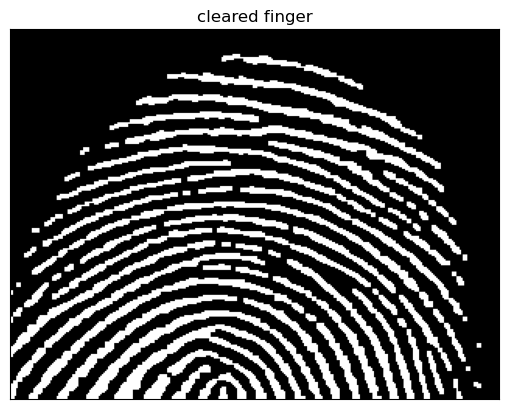

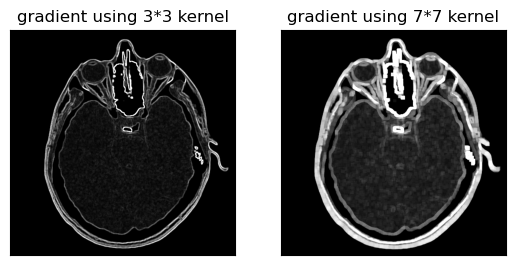

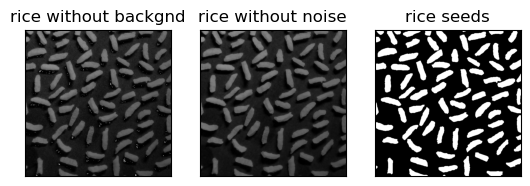

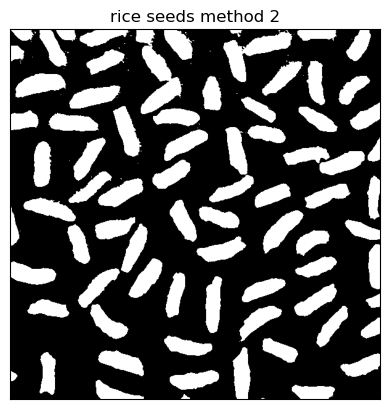

In [15]:
import cv2 as cv 
import matplotlib.pyplot as plt
import numpy as np 

noisy_finger=cv.imread("fingerprint.png",cv.IMREAD_GRAYSCALE)
n = 3
kernel_finger = cv.getStructuringElement(cv.MORPH_RECT,(n , n))
opening_finger = cv.morphologyEx(noisy_finger , cv.MORPH_OPEN, kernel_finger)
closing_finger = cv.morphologyEx(opening_finger , cv.MORPH_CLOSE, kernel_finger)

plt.imshow(closing_finger, cmap = 'gray',vmin  = 0, vmax = 255)
plt.title('cleared finger'), plt.xticks([]), plt.yticks([])

headct=cv.imread("headCT.png",cv.IMREAD_GRAYSCALE)
n1 = 3
n2 = 7
kernel_3 = cv.getStructuringElement(cv.MORPH_RECT,( n1 , n1))
gradient_3 = cv.morphologyEx(headct , cv.MORPH_GRADIENT, kernel_3)
kernel_7 = cv.getStructuringElement(cv.MORPH_RECT,( n2 , n2))
gradient_7 = cv.morphologyEx(headct , cv.MORPH_GRADIENT, kernel_7)

plt.figure()
plt.subplot(121),plt.imshow(gradient_3, cmap = 'gray',vmin  = 0, vmax = 255)
plt.title('gradient using 3*3 kernel'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(gradient_7, cmap = 'gray',vmin  = 0, vmax = 255)
plt.title('gradient using 7*7 kernel'), plt.xticks([]), plt.yticks([])

img_rice=cv.imread("rice.tif",cv.IMREAD_GRAYSCALE)
# method 1
n_ground=100
kernel_ground = cv.getStructuringElement(cv.MORPH_ELLIPSE,( n_ground , n_ground))
background_intensity=cv.morphologyEx(img_rice , cv.MORPH_OPEN, kernel_ground)
abs_rice=img_rice-background_intensity
n_noise = 4
kernel_noise = cv.getStructuringElement(cv.MORPH_ELLIPSE,( n_noise , n_noise))
opening_rice=cv.morphologyEx(abs_rice , cv.MORPH_OPEN, kernel_noise)
ret,rice_seed=cv.threshold(opening_rice,60,255,cv.THRESH_BINARY)

plt.figure()
plt.subplot(131),plt.imshow(abs_rice, cmap = 'gray',vmin  = 0, vmax = 255)
plt.title('rice without backgnd'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(opening_rice, cmap = 'gray',vmin  = 0, vmax = 255)
plt.title('rice without noise'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(rice_seed, cmap = 'gray',vmin  = 0, vmax = 255)
plt.title('rice seeds'), plt.xticks([]), plt.yticks([])

#method 2 ( method 1 is better )
kernel_rice=np.ones((100,100),np.uint8)
restored= cv.morphologyEx(img_rice ,cv.MORPH_TOPHAT,kernel_rice)
_,rice_seed_2=cv.threshold(restored,50,255,cv.THRESH_BINARY)

plt.figure()
plt.imshow(rice_seed_2, cmap = 'gray',vmin  = 0, vmax = 255)
plt.title('rice seeds method 2'), plt.xticks([]), plt.yticks([])

plt.show()
